In [3]:
import pandas as pd
df = pd.read_csv("adhddata.csv")
df.head()

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,...,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,...,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


In [4]:
df.shape[0]

2166383

In [5]:
df["Class"].value_counts()

Class
ADHD       1207069
Control     959314
Name: count, dtype: int64

In [6]:
df.groupby("Class")["ID"].nunique()

Class
ADHD       61
Control    60
Name: ID, dtype: int64

In [7]:
df.groupby(["Class", "ID"]).size()

Class    ID  
ADHD     v10p    14304
         v12p    17604
         v14p    17562
         v15p    43252
         v173    24241
                 ...  
Control  v56p    14139
         v57p    14692
         v58p    13918
         v59p    16513
         v60p    12929
Length: 121, dtype: int64

In [8]:
df.groupby("ID").size().describe()

count      121.000000
mean     17903.991736
std       6207.400652
min       7983.000000
25%      13697.000000
50%      16697.000000
75%      20115.000000
max      43252.000000
dtype: float64

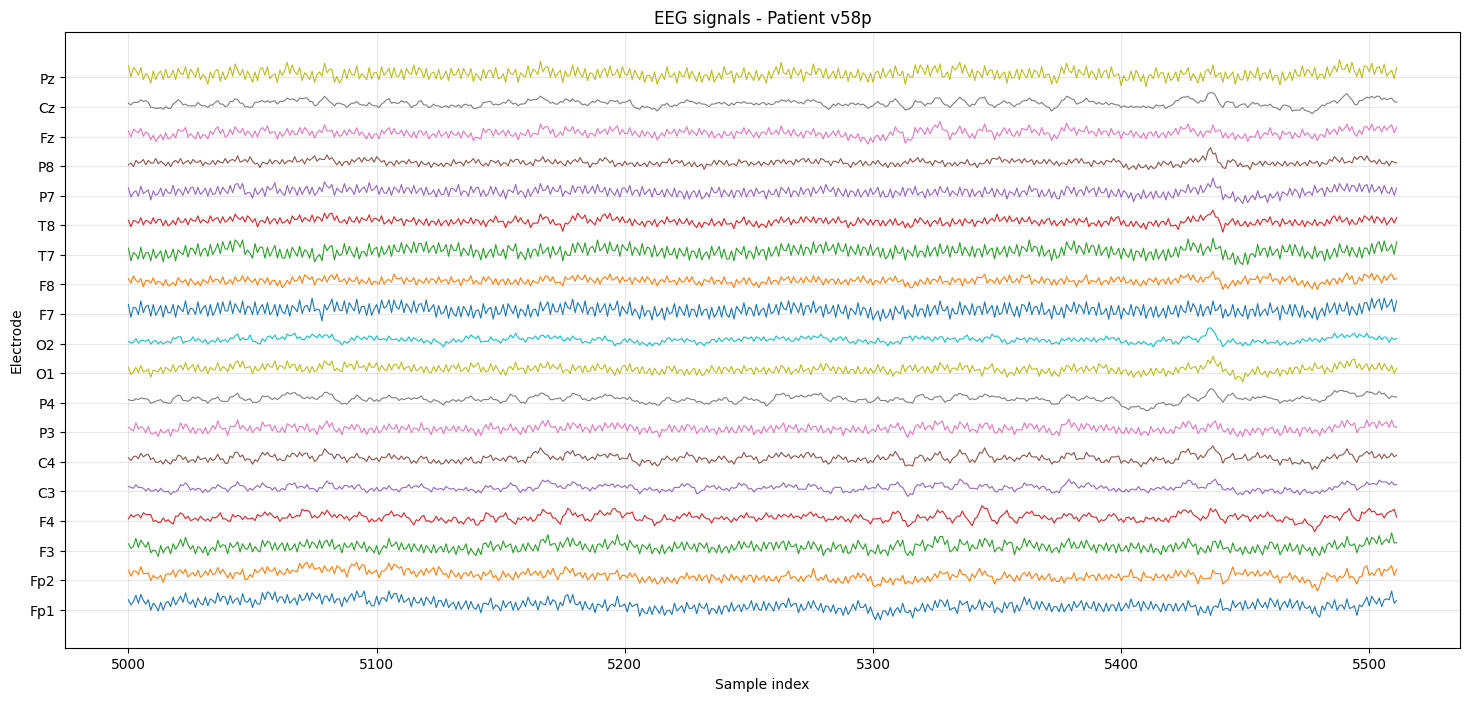

In [9]:
import matplotlib.pyplot as plt

channels = ["Fp1","Fp2","F3","F4","C3","C4","P3","P4","O1","O2",
            "F7","F8","T7","T8","P7","P8","Fz","Cz","Pz"]

patient_v58p = df[df["ID"] == "v58p"]

small_part = patient_v58p[channels].iloc[5000:5512]

x = range(5000, 5512)

plt.figure(figsize=(18, 8))

spacing = small_part.max().max() - small_part.min().min()

for i, ch in enumerate(channels):
    plt.plot(x, small_part[ch] + i * spacing, linewidth=0.8)

plt.yticks(
    [i * spacing for i in range(len(channels))],
    channels
)

plt.xlabel("Sample index")
plt.ylabel("Electrode")
plt.title("EEG signals - Patient v58p")
plt.grid(alpha=0.3)

plt.show()

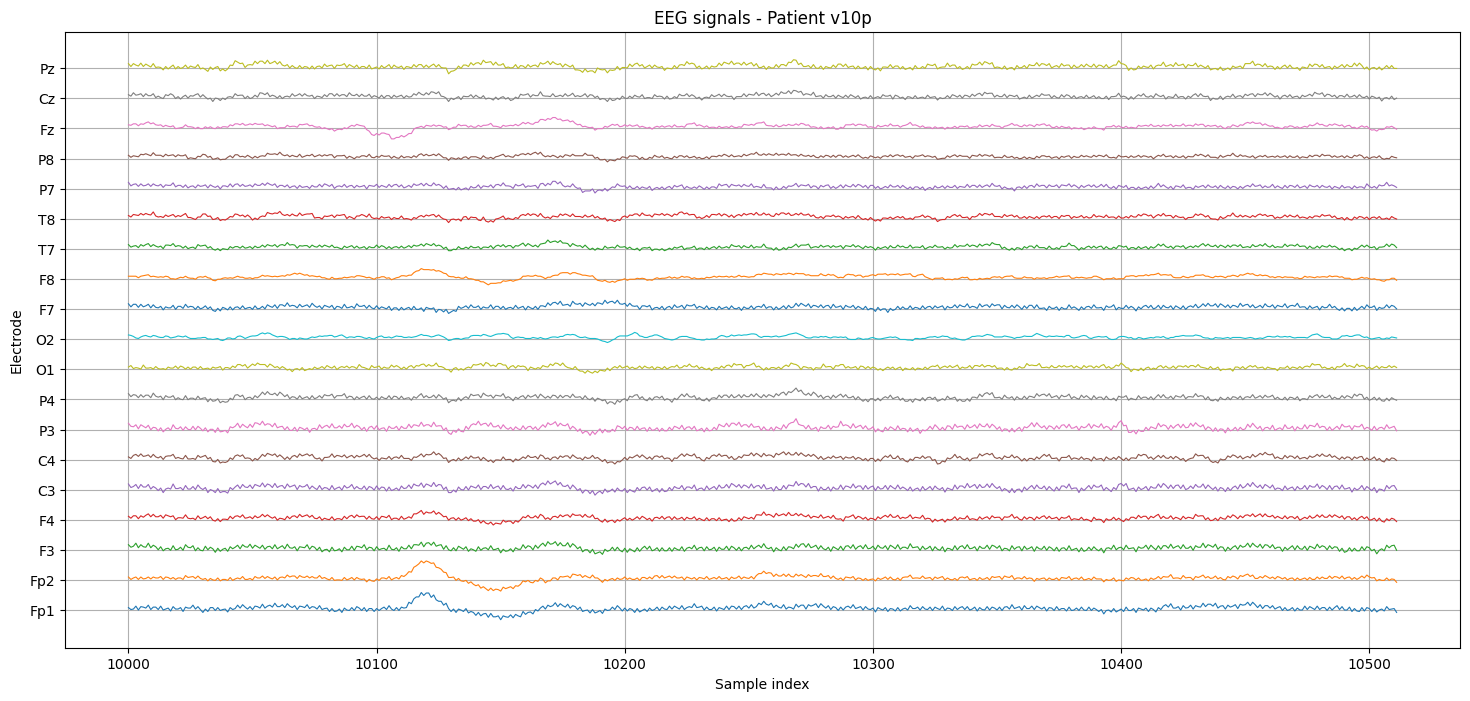

In [10]:
patient_v10p = df[df["ID"] == "v10p"]

small_part = patient_v10p[channels].iloc[10000:10512]

plt.figure(figsize=(18, 8))

offset = 0
spacing = small_part.max().max() - small_part.min().min()

for ch in channels:
    plt.plot(small_part.index, small_part[ch] + offset, linewidth=0.8)
    offset += spacing

plt.yticks(
    [i * spacing for i in range(len(channels))],
    channels
)

plt.xlabel("Sample index")
plt.ylabel("Electrode")
plt.title("EEG signals - Patient v10p")
plt.grid(True)

plt.show()

In [11]:
import mne
import numpy as np

montage = mne.channels.make_standard_montage("standard_1020")

coords = montage.get_positions()["ch_pos"]
x_coords = []
y_coords = []
z_coords = []

for ch in channels:
    x, y, z = coords[ch]
    x_coords.append(x)
    y_coords.append(y)
    z_coords.append(z)

coords_array = np.array([coords[ch] for ch in channels])

normalized_coords = coords_array / np.linalg.norm(coords_array, axis=1)[:, np.newaxis]

for ch, xyz in zip(channels, normalized_coords):
    print(f"{ch}: ({xyz[0]:.3f}, {xyz[1]:.3f}, {xyz[2]:.3f})")



Fp1: (-0.330, 0.941, -0.078)
Fp2: (0.331, 0.940, -0.078)
F3: (-0.595, 0.629, 0.500)
F4: (0.607, 0.636, 0.478)
C3: (-0.707, -0.126, 0.696)
C4: (0.721, -0.117, 0.683)
P3: (-0.481, -0.715, 0.508)
P4: (0.499, -0.704, 0.507)
O1: (-0.252, -0.965, 0.076)
O2: (0.256, -0.964, 0.076)
F7: (-0.848, 0.512, -0.138)
F8: (0.846, 0.515, -0.139)
T7: (-0.977, -0.186, -0.108)
T8: (0.979, -0.173, -0.109)
P7: (-0.702, -0.712, -0.024)
P8: (0.707, -0.707, -0.025)
Fz: (0.004, 0.661, 0.751)
Cz: (0.004, -0.091, 0.996)
Pz: (0.003, -0.701, 0.714)


In [13]:
import plotly.graph_objects as go

fig = go.Figure()

# electrodes
fig.add_trace(go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    mode="markers+text",
    text=channels,
    textposition="top center",
    marker=dict(size=6)
))

fig.update_layout(
    title="10-20 EEG Electrode Positions (MNE standard_1020)",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=800,
    height=800
)

fig.show()

In [ ]:
# First translate cartesian coordinates into latitude and longitude, then use AEP

def aep_projection(xyz):
    x, y, z = xyz

    phi = np.arcsin(z)          # latitude
    lam = np.arctan2(y, x)      # longitude

    c = np.pi/2 - phi

    X = c * np.sin(lam)
    Y = -c * np.cos(lam)

    return X, Y

aep_coords = {}

for ch in channels:
    xyz = coords[ch] / np.linalg.norm(coords[ch])
    aep_coords[ch] = aep_projection(xyz)

    print(ch, aep_coords[ch])

Fp1 (np.float64(1.5562647435459493), np.float64(0.5459113622412959))
Fp2 (np.float64(1.5557991572459133), np.float64(-0.5474386768383054))
F3 (np.float64(0.7608707409609053), np.float64(0.7197923853102836))
F4 (np.float64(0.7760443105090646), np.float64(-0.740766711016521))
C3 (np.float64(-0.14033037550633923), np.float64(0.7885112851415412))
C4 (np.float64(-0.1312829100262466), np.float64(-0.8083661208270063))
P3 (np.float64(-0.861588965259778), np.float64(0.5796646785189409))
P4 (np.float64(-0.848287504809005), np.float64(-0.6010851047216204))
O1 (np.float64(-1.446239445787657), np.float64(0.3782943317835702))
O2 (np.float64(-1.4448449037430262), np.float64(-0.38444602628875535))
F7 (np.float64(0.8841149299326171), np.float64(1.462542735497995))
F8 (np.float64(0.888666371376423), np.float64(-1.461244090862916))
T7 (np.float64(-0.31402002845558746), np.float64(1.6498386895848953))
T8 (np.float64(-0.29211127515054974), np.float64(-1.6546139610181725))
P7 (np.float64(-1.1356094258564475

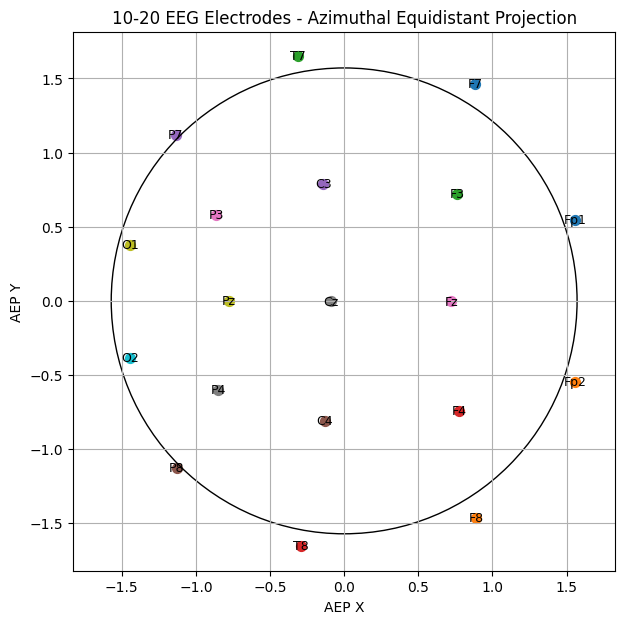

In [ ]:
plt.figure(figsize=(7,7))

for ch, (x, y) in aep_coords.items():
    plt.scatter(x, y, s=50)
    plt.text(x, y, ch, fontsize=9,
             horizontalalignment="center",
             verticalalignment="center")
    
circle = plt.Circle((0,0), np.pi/2, fill=False)
plt.gca().add_patch(circle)

plt.axis("equal")
plt.xlabel("AEP X")
plt.ylabel("AEP Y")
plt.title("10-20 EEG Electrodes - Azimuthal Equidistant Projection")
plt.grid(True)

plt.show()

In [14]:
from scipy.signal import welch
SF = 128
df["is_ADHD"] = (df["Class"] == "ADHD").astype(int)

subjects = df.groupby("ID")

In [15]:
matrices = []
adhd_labels = []
subject_ids = []

for subject_id, group in subjects:
    signal = group[channels].values.T
    label = group["is_ADHD"].iloc[0]
    channel_powers = []

    for channel_index in range(signal.shape[0]):
        freq, psd = welch(signal[channel_index], fs=SF, nperseg=256)
        band_powers = []

        for low in range(1, 41):
            mask = (freq >= low) & (freq < low + 1)
            band_powers.append(psd[mask].sum())
        channel_powers.append(band_powers)

    sub_matrix = np.array(channel_powers)
    matrices.append(sub_matrix)
    adhd_labels.append(label)
    subject_ids.append(subject_id)

power_tensor = np.stack(matrices)
labels = np.array(adhd_labels)

power_tensor.shape, labels.shape

((121, 19, 40), (121,))

In [ ]:
import numpy as np
np.save("power_tensor.npy", power_tensor)
np.save("labels.npy", labels)
np.save("subject_ids.npy", np.array(subject_ids))

power_tensor_loaded = np.load("power_tensor.npy")
labels_loaded = np.load("labels.npy")
subject_ids_loaded = np.load("subject_ids.npy")
print(power_tensor_loaded.shape)   
print(labels_loaded)               
print(subject_ids_loaded)  

NameError: name 'np' is not defined